# M-03 — Optimize AI Model Performance

**Fase:** Modeling  
**Proyecto:** Healthcare AI Billing Auditor  
**Metodología:** ASUM-DM  

Implementación de CNN 1D con Transfer Learning usando sentence-transformers 
para clasificación multiclase de inconsistencias clínicas entre la Historia 
Clínica y la Prefactura. Se comparan resultados contra el baseline Random Forest 
del M-02 para justificar el modelo final.

**Clases objetivo:**
- CONSISTENTE
- SIN_SOPORTE_CLINICO
- DIAGNOSTICO_NO_RELACIONADO
- NO_FACTURADO
- CODIGO_NO_COINCIDE
- CANTIDAD_DISCORDANTE


In [1]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN
# ============================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib
import os

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print("✅ Librerías cargadas")
print(f" TensorFlow: {tf.__version__}")

Matplotlib is building the font cache; this may take a moment.
c:\Users\Diego Bejarano\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Librerías cargadas
 TensorFlow: 2.21.0


In [2]:
# ── Carga de datos ─────────────────────────────────────────
DATA_PATH   = '../data/master/'
MODELS_PATH = '../models/'

os.makedirs(MODELS_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH + 'master_dataset_features.csv')

print(f"Dataset cargado: {df.shape[0]:,} registros")
print(f"\nDistribución de clases:")
print(df['tipo_alerta'].value_counts())

Dataset cargado: 3,126 registros

Distribución de clases:
tipo_alerta
CONSISTENTE                   2477
SIN_SOPORTE_CLINICO            157
DIAGNOSTICO_NO_RELACIONADO     152
NO_FACTURADO                   152
CODIGO_NO_COINCIDE             120
CANTIDAD_DISCORDANTE            68
Name: count, dtype: int64


In [3]:
# ── Preparación de textos ──────────────────────────────────
# Concatenamos las 3 descripciones clínicas en un solo texto
# que alimentará el modelo de embeddings

df['texto_clinico'] = (
    df['descripcion_diagnostico'].fillna('') + ' | ' +
    df['descripcion'].fillna('') + ' | ' +
    df['descripcion_servicio_facturado'].fillna('')
)

print("Ejemplos de texto clínico:")
for i, texto in enumerate(df['texto_clinico'].head(3)):
    print(f"\n  [{i+1}] {texto}")

Ejemplos de texto clínico:

  [1] Infarto agudo del miocardio, no especificado | Consulta de primera vez medicina general | Consulta de primera vez medicina general

  [2] Infarto agudo del miocardio, no especificado | Electrocardiograma | Electrocardiograma

  [3] Infarto agudo del miocardio, no especificado | Angioplastia coronaria | 


In [4]:
# ── Transfer Learning: generación de embeddings ────────────
# Usamos sentence-transformers como componente preentrenado
# para convertir texto clínico en vectores semánticos de 384 dim

print("Cargando modelo preentrenado...")
embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("Generando embeddings (esto puede tardar unos minutos)...")
embeddings = embedder.encode(
    df['texto_clinico'].tolist(),
    batch_size  = 32,
    show_progress_bar = True
)

print(f"\n✅ Embeddings generados")
print(f"   Shape: {embeddings.shape}")
print(f"   Dimensiones por texto: {embeddings.shape[1]}")

Cargando modelo preentrenado...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2802.28it/s]


Generando embeddings (esto puede tardar unos minutos)...


Batches: 100%|██████████| 98/98 [00:50<00:00,  1.93it/s]


✅ Embeddings generados
   Shape: (3126, 384)
   Dimensiones por texto: 384


In [5]:
# ── Encoding del target ────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df['tipo_alerta'])

print("Clases codificadas:")
for i, clase in enumerate(le.classes_):
    count = (df['tipo_alerta'] == clase).sum()
    print(f"  {i} → {clase} ({count} registros)")

# Guardar el encoder para inferencia posterior
joblib.dump(le, MODELS_PATH + 'label_encoder.pkl')
print("\n✅ LabelEncoder guardado")

Clases codificadas:
  0 → CANTIDAD_DISCORDANTE (68 registros)
  1 → CODIGO_NO_COINCIDE (120 registros)
  2 → CONSISTENTE (2477 registros)
  3 → DIAGNOSTICO_NO_RELACIONADO (152 registros)
  4 → NO_FACTURADO (152 registros)
  5 → SIN_SOPORTE_CLINICO (157 registros)

✅ LabelEncoder guardado


In [6]:
# ── Split train / test ─────────────────────────────────────
X = embeddings.reshape(embeddings.shape[0], embeddings.shape[1], 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

n_clases = len(le.classes_)

print(f"Train: {X_train.shape[0]:,} registros")
print(f"Test:  {X_test.shape[0]:,} registros")
print(f"Clases: {n_clases}")
print(f"Shape input CNN: {X_train.shape}")

Train: 2,500 registros
Test:  626 registros
Clases: 6
Shape input CNN: (2500, 384, 1)


In [14]:
# ── Arquitectura CNN 1D ────────────────────────────────────
# Fine Tuning sobre los embeddings semánticos generados
# por sentence-transformers

# model = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=(384, 1)),

#     # Bloque convolucional 1
#     tf.keras.layers.Conv1D(filters=128, kernel_size=3,
#                            activation='relu', padding='same'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling1D(pool_size=2),
#     tf.keras.layers.Dropout(0.3),

#     # Bloque convolucional 2
#     tf.keras.layers.Conv1D(filters=64, kernel_size=3,
#                            activation='relu', padding='same'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling1D(pool_size=2),
#     tf.keras.layers.Dropout(0.3),

#     # Clasificador
#     tf.keras.layers.GlobalAveragePooling1D(),
#     tf.keras.layers.Dense(64, activation='relu'),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(n_clases, activation='softmax')
# ])

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(384,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,230 (516.52 KB)

 Trainable params: 132,230 (516.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Compilar y entrenar ────────────────────────────────────
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# Class weights para manejar desbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(y_train),
    y            = y_train
)
class_weight_dict = dict(enumerate(class_weights))

# Early stopping para evitar overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor  = 'val_loss',
    patience = 10,
    restore_best_weights = True
)

history = model.fit(
    X_train, y_train,
    epochs           = 50,
    batch_size       = 32,
    validation_split = 0.2,
    class_weight     = class_weight_dict,
    callbacks        = [early_stopping],
    verbose          = 1
)

print("✅ Modelo entrenado")

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2620 - loss: 1.7953 - val_accuracy: 0.3920 - val_loss: 1.6446
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3410 - loss: 1.6203 - val_accuracy: 0.4180 - val_loss: 1.4662
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4080 - loss: 1.4478 - val_accuracy: 0.4120 - val_loss: 1.4835
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4330 - loss: 1.2969 - val_accuracy: 0.4620 - val_loss: 1.3278
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4310 - loss: 1.1916 - val_accuracy: 0.4160 - val_loss: 1.3345
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4360 - loss: 1.1192 - val_accuracy: 0.4680 - val_loss: 1.2078
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4460 - loss: 1.0540 - val_accuracy: 0.4840 - val_loss: 1.2218
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4340 - loss: 1.0596 - val_accuracy: 0.4520 - val_loss

In [18]:
pred = model.predict(X_test)
pred = np.argmax(pred, axis=1)

print(classification_report(y_test, pred, target_names=le.classes_))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
                            precision    recall  f1-score   support

      CANTIDAD_DISCORDANTE       0.08      1.00      0.15        14
        CODIGO_NO_COINCIDE       0.62      0.62      0.62        24
               CONSISTENTE       0.92      0.52      0.66       496
DIAGNOSTICO_NO_RELACIONADO       0.09      0.23      0.13        30
              NO_FACTURADO       0.75      0.90      0.82        30
       SIN_SOPORTE_CLINICO       0.03      0.03      0.03        32

                  accuracy                           0.51       626
                 macro avg       0.42      0.55      0.40       626
              weighted avg       0.80      0.51      0.60       626



In [10]:
print(np.unique(y_train, return_counts=True))

(array([0, 1, 2, 3, 4, 5]), array([  54,   96, 1981,  122,  122,  125]))


In [11]:
print(class_weight_dict)

{0: np.float64(7.716049382716049), 1: np.float64(4.340277777777778), 2: np.float64(0.21033148241628807), 3: np.float64(3.4153005464480874), 4: np.float64(3.4153005464480874), 5: np.float64(3.3333333333333335)}


In [12]:
pred = model.predict(X_test)

print(pred[:5])
print(np.sum(pred, axis=1)[:5])

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[0.12692684 0.2319152  0.20342174 0.26845917 0.10210894 0.06716806]
 [0.12461245 0.2373519  0.20602557 0.26540622 0.10102367 0.0655802 ]
 [0.13471086 0.23073356 0.19374682 0.25996152 0.10820969 0.07263749]
 [0.13487922 0.22740282 0.19304633 0.26783097 0.10542953 0.07141113]
 [0.12745327 0.23475404 0.20281452 0.26567805 0.10224365 0.06705644]]
[0.99999994 1.0000001  0.9999999  1.         0.99999994]


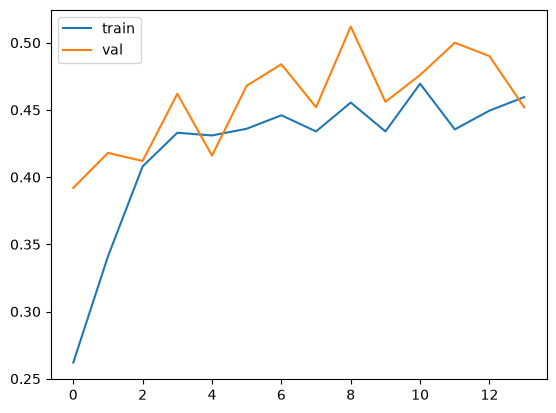

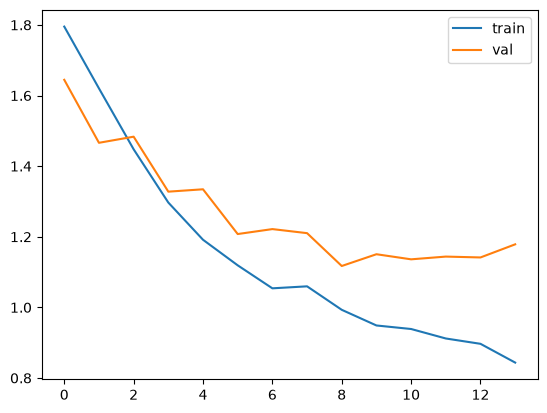

In [17]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.show()

plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.show()